In [1]:
import great_expectations as ge
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import IterativeImputer
imp = IterativeImputer(random_state=0, max_iter=50)
scaler = StandardScaler()

In [2]:
a = ge.get_context
df_uci = pd.read_parquet('../data/processed/uci_air_quality_cleaned.parquet')
df_global = pd.read_parquet('../data/processed/global_air_quality.parquet')

In [3]:
df_uci

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
DateTime,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.00,150.0,11.881723,1045.50,166.000000,1056.25,113.000000,1692.00,1267.50,13.600000,48.875000,0.757754
2004-03-10 19:00:00,2.0,1292.25,112.0,9.397165,954.75,103.000000,1173.75,92.000000,1558.75,972.25,13.300000,47.700001,0.725487
2004-03-10 20:00:00,2.2,1402.00,88.0,8.997817,939.25,131.000000,1140.00,114.000000,1554.50,1074.00,11.900000,53.975002,0.750239
2004-03-10 21:00:00,2.2,1375.50,80.0,9.228796,948.25,172.000000,1092.00,122.000000,1583.75,1203.25,11.000000,60.000000,0.786713
2004-03-10 22:00:00,1.6,1272.25,51.0,6.518224,835.50,131.000000,1205.00,116.000000,1490.00,1110.00,11.150000,59.575001,0.788794
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2005-04-04 10:00:00,3.1,1314.25,NaN,13.529605,1101.25,471.700012,538.50,189.800003,1374.25,1728.50,21.850000,29.250000,0.756824
2005-04-04 11:00:00,2.4,1162.50,NaN,11.355158,1027.00,353.299988,603.75,179.199997,1263.50,1269.00,24.325001,23.725000,0.711864
2005-04-04 12:00:00,2.4,1142.00,NaN,12.374538,1062.50,293.000000,603.25,174.699997,1240.75,1092.00,26.900000,18.350000,0.640649


In [4]:
df_uci.corr()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
CO(GT),1.000000,0.879292,0.889734,0.931091,0.915519,0.795054,-0.703433,0.683533,0.630700,0.854183,0.022113,0.048896,0.048555
PT08.S1(CO),0.879292,1.000000,0.790677,0.883821,0.892972,0.713687,-0.771918,0.641696,0.682874,0.899326,0.048628,0.114607,0.135323
NMHC(GT),0.889734,0.790677,1.000000,0.902599,0.877691,0.812685,-0.771111,0.731193,0.853278,0.766731,0.391730,-0.191486,0.269734
C6H6(GT),0.931091,0.883821,0.902599,1.000000,0.981962,0.718914,-0.735711,0.614753,0.765717,0.865727,0.198891,-0.061643,0.167909
PT08.S2(NMHC),0.915519,0.892972,0.877691,0.981962,1.000000,0.704483,-0.796687,0.646520,0.777235,0.880590,0.241330,-0.090352,0.186906
NOx(GT),0.795054,0.713687,0.812685,0.718914,0.704483,1.000000,-0.655690,0.763170,0.233777,0.787056,-0.269713,0.221022,-0.149279
PT08.S3(NOx),-0.703433,-0.771918,-0.771111,-0.735711,-0.796687,-0.655690,1.000000,-0.652138,-0.538460,-0.796554,-0.145133,-0.056730,-0.232021
NO2(GT),0.683533,0.641696,0.731193,0.614753,0.646520,0.763170,-0.652138,1.000000,0.157678,0.708259,-0.186369,-0.091845,-0.334798
PT08.S4(NO2),0.630700,0.682874,0.853278,0.765717,0.777235,0.233777,-0.538460,0.157678,1.000000,0.591137,0.561333,-0.032188,0.629644
PT08.S5(O3),0.854183,0.899326,0.766731,0.865727,0.880590,0.787056,-0.796554,0.708259,0.591137,1.000000,-0.027193,0.124952,0.070738


In [5]:
time_diff = df_uci.index.to_series().diff()
time_diff.describe()

count               9356
mean     0 days 01:00:00
std      0 days 00:00:00
min      0 days 01:00:00
25%      0 days 01:00:00
50%      0 days 01:00:00
75%      0 days 01:00:00
max      0 days 01:00:00
Name: DateTime, dtype: object

<Axes: ylabel='DateTime'>

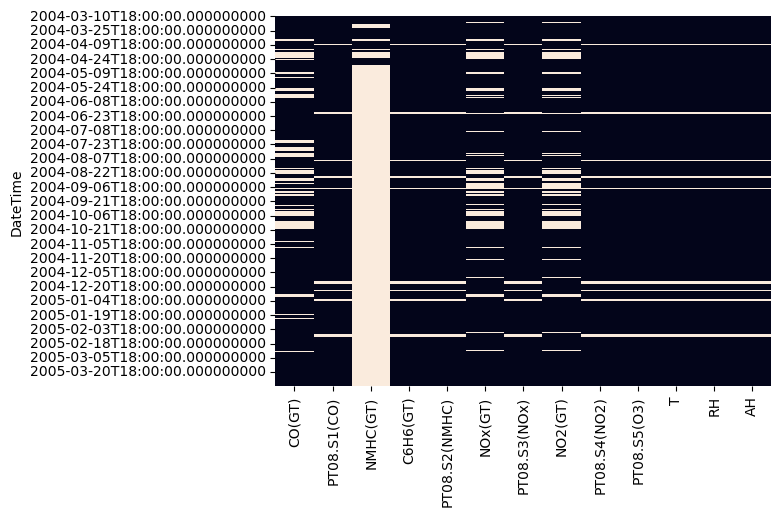

In [6]:
plt.ylabel('Date Time')
sns.heatmap(df_uci.isna(), cbar=False)

In [7]:
df_uci_copy = df_uci.copy()
df_uci_copy.drop(columns=['NMHC(GT)'], inplace=True)

In [8]:
valid = df_uci_copy['CO(GT)'].dropna()
gap = valid.index.to_series().diff()
gap.sort_values(ascending=False)

DateTime
2004-10-20 16:00:00   7 days 06:00:00
2004-04-23 05:00:00   6 days 03:00:00
2004-10-07 16:00:00   5 days 23:00:00
2004-07-31 05:00:00   5 days 03:00:00
2005-01-01 01:00:00   4 days 01:00:00
                            ...      
2004-07-16 18:00:00   0 days 01:00:00
2004-07-16 17:00:00   0 days 01:00:00
2004-07-16 16:00:00   0 days 01:00:00
2005-04-04 14:00:00   0 days 01:00:00
2004-03-10 18:00:00               NaT
Name: DateTime, Length: 7674, dtype: timedelta64[ns]

In [9]:
valid.index

DatetimeIndex(['2004-03-10 18:00:00', '2004-03-10 19:00:00',
               '2004-03-10 20:00:00', '2004-03-10 21:00:00',
               '2004-03-10 22:00:00', '2004-03-10 23:00:00',
               '2004-03-11 00:00:00', '2004-03-11 01:00:00',
               '2004-03-11 02:00:00', '2004-03-11 03:00:00',
               ...
               '2005-04-04 05:00:00', '2005-04-04 06:00:00',
               '2005-04-04 07:00:00', '2005-04-04 08:00:00',
               '2005-04-04 09:00:00', '2005-04-04 10:00:00',
               '2005-04-04 11:00:00', '2005-04-04 12:00:00',
               '2005-04-04 13:00:00', '2005-04-04 14:00:00'],
              dtype='datetime64[ns]', name='DateTime', length=7674, freq=None)

## Xử lý missing data

In [10]:
#Hàm để fill na value
def impute_value(df, cols):

    for col in cols:
        df[f"{col}_raw"] = df[col]
        df[f"{col}_imputed"] = df[col].isna()

    df[cols] = (
        df[cols]
        .interpolate(method="time", limit=2)
        .ffill(limit=4)
    )
    scaled = scaler.fit_transform(df[cols])
    imputer = imp.fit_transform(scaled)
    df[cols] = scaler.inverse_transform(imputer)

    return df

In [11]:
df_uci_copy.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9357 entries, 2004-03-10 18:00:00 to 2005-04-04 14:00:00
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CO(GT)         7674 non-null   float32
 1   PT08.S1(CO)    8991 non-null   float32
 2   C6H6(GT)       8991 non-null   float32
 3   PT08.S2(NMHC)  8991 non-null   float32
 4   NOx(GT)        7718 non-null   float32
 5   PT08.S3(NOx)   8991 non-null   float32
 6   NO2(GT)        7715 non-null   float32
 7   PT08.S4(NO2)   8991 non-null   float32
 8   PT08.S5(O3)    8991 non-null   float32
 9   T              8991 non-null   float32
 10  RH             8991 non-null   float32
 11  AH             8991 non-null   float32
dtypes: float32(12)
memory usage: 511.7 KB


In [12]:
cols = ['CO(GT)','PT08.S1(CO)','C6H6(GT)','PT08.S2(NMHC)','NOx(GT)','PT08.S3(NOx)',	'NO2(GT)','PT08.S4(NO2)',	'PT08.S5(O3)','T','RH','AH']
df_uci_copy = impute_value(df_uci_copy,cols)

D:\anaconda3\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [13]:
df_uci_copy.describe()

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,...,C6H6(GT)_raw,PT08.S2(NMHC)_raw,NOx(GT)_raw,PT08.S3(NOx)_raw,NO2(GT)_raw,PT08.S4(NO2)_raw,PT08.S5(O3)_raw,T_raw,RH_raw,AH_raw
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,...,8991.000000,8991.000000,7718.000000,8991.000000,7715.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000
mean,2.097562,1102.555786,10.190272,942.769714,236.537354,832.140991,109.295296,1455.751465,1029.379272,18.264782,...,10.082993,939.029236,246.881256,835.370911,113.075516,1456.143433,1022.780640,18.316055,49.232361,1.025530
std,1.443965,217.663467,7.493811,267.877686,207.589172,256.335571,47.309483,342.293579,402.552734,8.752636,...,7.449648,266.828857,212.971237,256.814911,48.359291,346.204742,398.480621,8.832889,17.316393,0.403813
min,0.044674,647.250000,0.149048,383.250000,-78.758553,-22.363789,-6.393669,551.000000,220.999954,-1.900000,...,0.149048,383.250000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.175000,0.184679
25%,1.000000,939.250000,4.519882,738.750000,91.999992,656.750000,74.000000,1235.000000,736.750000,11.875000,...,4.436942,734.375000,98.000000,657.875000,78.000000,1226.625000,731.375000,11.787500,35.812500,0.736769
50%,1.730929,1065.750000,8.338445,911.750000,173.000000,806.000000,105.000000,1459.000000,968.000000,17.724998,...,8.239851,909.000000,179.800003,805.500000,109.000000,1462.750000,963.250000,17.750000,49.549999,0.995395
75%,2.800000,1234.250000,14.073312,1117.750000,314.000000,967.000000,137.000000,1668.250000,1281.250000,24.225000,...,13.988478,1116.250000,326.000000,969.250000,142.000000,1673.500000,1273.375000,24.400000,62.500000,1.313701
max,11.900000,2039.750122,63.741478,2214.000000,1479.000000,2682.750000,339.700012,2775.000000,2708.976807,44.600002,...,63.741478,2214.000000,1479.000000,2682.750000,339.700012,2775.000000,2522.750000,44.600002,88.724998,2.231036


In [14]:
df_uci_copy.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9357 entries, 2004-03-10 18:00:00 to 2005-04-04 14:00:00
Data columns (total 36 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CO(GT)                 9357 non-null   float32
 1   PT08.S1(CO)            9357 non-null   float32
 2   C6H6(GT)               9357 non-null   float32
 3   PT08.S2(NMHC)          9357 non-null   float32
 4   NOx(GT)                9357 non-null   float32
 5   PT08.S3(NOx)           9357 non-null   float32
 6   NO2(GT)                9357 non-null   float32
 7   PT08.S4(NO2)           9357 non-null   float32
 8   PT08.S5(O3)            9357 non-null   float32
 9   T                      9357 non-null   float32
 10  RH                     9357 non-null   float32
 11  AH                     9357 non-null   float32
 12  CO(GT)_raw             7674 non-null   float32
 13  CO(GT)_imputed         9357 non-null   bool   
 14  PT08.S1(CO)_raw     

In [15]:
df_uci_copy[df_uci_copy['PT08.S4(NO2)'].isna()]

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,...,PT08.S4(NO2)_raw,PT08.S4(NO2)_imputed,PT08.S5(O3)_raw,PT08.S5(O3)_imputed,T_raw,T_imputed,RH_raw,RH_imputed,AH_raw,AH_imputed
DateTime,,,,,,,,,,,,,,,,,,,,,


## Xử lý outlier

**Đầu tiên xử lý các giá trị đang mang dấu âm trước**

In [16]:
df_global_copy = df_global.copy()

In [17]:
def handle_negative_value(df, cols):
    df_clean = df.copy()
    for col in cols:
        df_clean.loc[df_clean[col]<=0,col] = np.nan

        df_clean[col] = df_clean[col].interpolate(method='linear')
    return df_clean
df_uci_col = ['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)']
df_uci_capped = handle_negative_value(df_uci_copy, df_uci_col)
df_global_col = ['CO', 'NO2', 'SO2', 'O3', 'PM2.5', 'PM10', 'AQI']
df_global_capped = handle_negative_value(df_global_copy, df_global_col)


In [18]:
df_uci_capped.describe()

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,...,C6H6(GT)_raw,PT08.S2(NMHC)_raw,NOx(GT)_raw,PT08.S3(NOx)_raw,NO2(GT)_raw,PT08.S4(NO2)_raw,PT08.S5(O3)_raw,T_raw,RH_raw,AH_raw
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,...,8991.000000,8991.000000,7718.000000,8991.000000,7715.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000
mean,2.097562,1102.555786,10.190272,942.769714,237.068558,832.151306,109.297279,1455.751465,1029.379272,18.264782,...,10.082993,939.029236,246.881256,835.370911,113.075516,1456.143433,1022.780640,18.316055,49.232361,1.025530
std,1.443965,217.663467,7.493811,267.877686,207.007721,256.303101,47.305023,342.293579,402.552734,8.752636,...,7.449648,266.828857,212.971237,256.814911,48.359291,346.204742,398.480621,8.832889,17.316393,0.403813
min,0.044674,647.250000,0.149048,383.250000,1.003945,7.713178,1.999993,551.000000,220.999954,-1.900000,...,0.149048,383.250000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.175000,0.184679
25%,1.000000,939.250000,4.519882,738.750000,92.172188,656.750000,74.000000,1235.000000,736.750000,11.875000,...,4.436942,734.375000,98.000000,657.875000,78.000000,1226.625000,731.375000,11.787500,35.812500,0.736769
50%,1.730929,1065.750000,8.338445,911.750000,173.000000,806.000000,105.000000,1459.000000,968.000000,17.724998,...,8.239851,909.000000,179.800003,805.500000,109.000000,1462.750000,963.250000,17.750000,49.549999,0.995395
75%,2.800000,1234.250000,14.073312,1117.750000,314.000000,967.000000,137.000000,1668.250000,1281.250000,24.225000,...,13.988478,1116.250000,326.000000,969.250000,142.000000,1673.500000,1273.375000,24.400000,62.500000,1.313701
max,11.900000,2039.750122,63.741478,2214.000000,1479.000000,2682.750000,339.700012,2775.000000,2708.976807,44.600002,...,63.741478,2214.000000,1479.000000,2682.750000,339.700012,2775.000000,2522.750000,44.600002,88.724998,2.231036


**Tính toán IQR và loại bỏ outlier theo threshold mong muốn (ví dụ minh hòa: AQI > 500 là siêu ô nhiêm nhwung nếu mà > 1000 thì là vô lý )** 

In [19]:
def handle_outlier(df, cols , domain_limit):
    df_clean = df.copy()
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        upper_boundary = Q3 + 1.5*IQR
        lower_boundary = Q1 * 1.5*IQR
        if col in domain_limit:
            limit_col = domain_limit[col]
            exceed_limit_mask = (df[col] > upper_boundary) & (df[col] > limit_col)
            df_clean.loc[exceed_limit_mask, col] = np.nan
        df_clean[col] = df_clean[col].interpolate(method='linear')
    return df_clean

domain_limits_global = {'CO': 5000, 'NO2': 500, 'SO2': 500, 'O3': 500, 'PM2.5': 1000, 'PM10': 1000, 'AQI': 1000}
df_global_capped = handle_outlier(df_global_capped, df_global_col, domain_limits_global)

domain_limits_uci = {col: 5000 for col in df_uci_col}
df_uci_capped = handle_outlier(df_uci_capped, df_uci_col, domain_limits_uci)

**Kieemr tra qua boxplot và log**

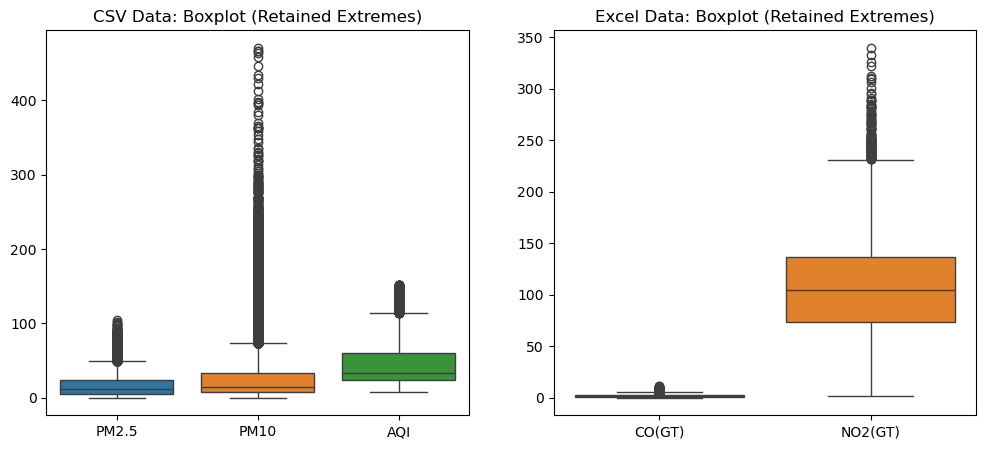

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df_global_capped[['PM2.5', 'PM10', 'AQI']], ax=axes[0])
axes[0].set_title('CSV Data: Boxplot (Retained Extremes)')

sns.boxplot(data=df_uci_capped[['CO(GT)', 'NO2(GT)']], ax=axes[1])
axes[1].set_title('Excel Data: Boxplot (Retained Extremes)')
plt.show()

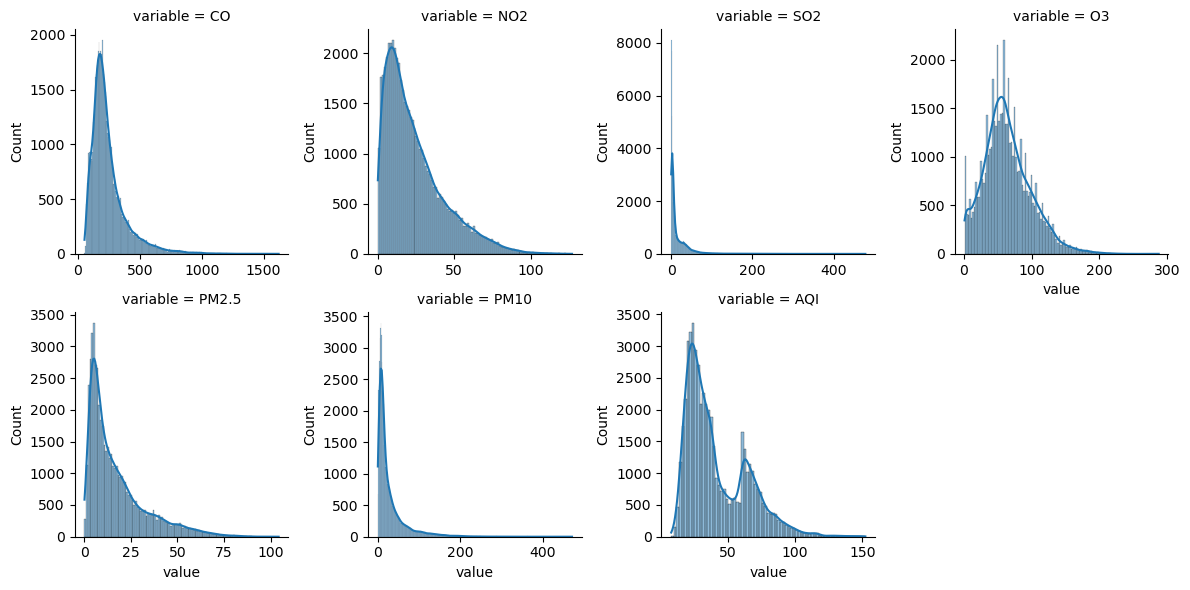

<Axes: ylabel='CO'>

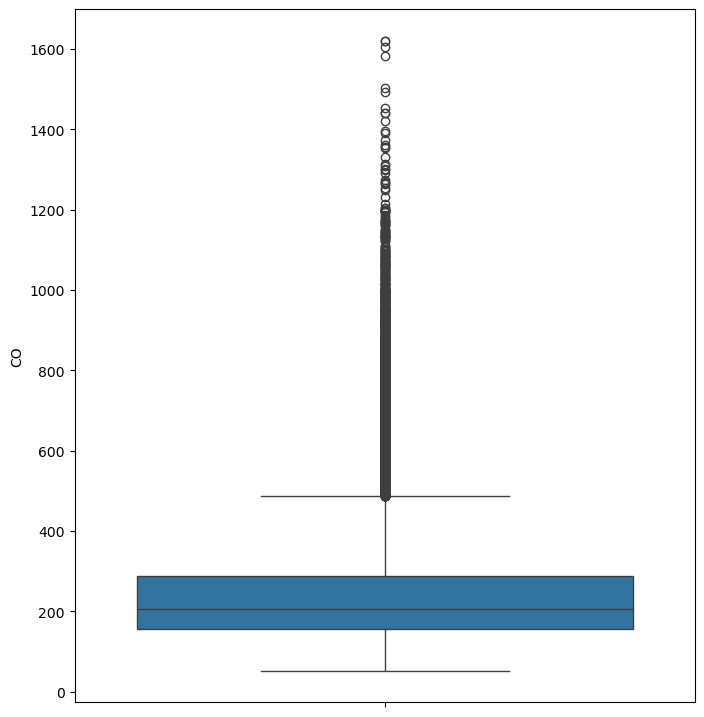

In [21]:
df_numeric = df_global_capped.melt(value_vars=['CO','NO2','SO2','O3','PM2.5','PM10','AQI'])

g = sns.FacetGrid(df_numeric, col="variable", col_wrap=4, sharex=False, sharey=False)
g.map(sns.histplot, "value", kde=True)
plt.show()
plt.figure(figsize=(8,9))
plt.xticks(rotation='vertical')
sns.boxplot(data=df_global_capped['CO'])
#full lệch phải

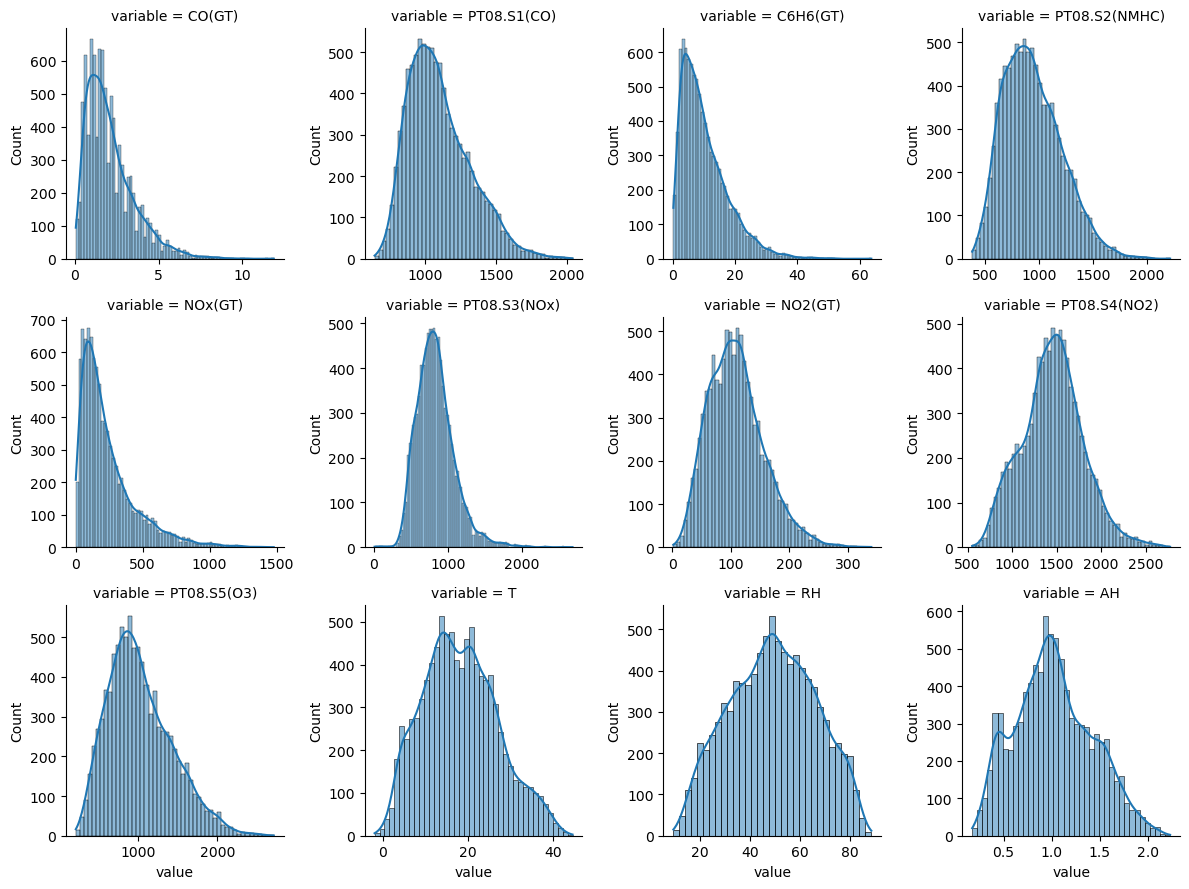

In [22]:
df_melt = df_uci_capped.melt(value_vars=['CO(GT)', 'PT08.S1(CO)',  'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH'])

g = sns.FacetGrid(df_melt, col="variable", col_wrap=4, sharex=False, sharey=False)
g.map(sns.histplot, "value", kde=True)

plt.show()

## Tính AQI cho UCI ( hiện chỉ có CO va NO2 nên AQI chỉ mang tính chất tham khảo )

In [23]:
AQI_breakpint = {
    'CO':[
        (0.0, 4.4, 0, 50),
        (4.5, 9.4, 51, 100),
        (9.5, 12.4, 101, 150),
        (12.5, 15.4, 151, 200),
        (15.5, 30.4, 201, 300),
        (30.5, 40.4, 301, 400),
        (40.5, 50.4, 401, 500)
    ],
    'NO2':[
        (0.0, 0.053, 0,50),
        (0.054,0.1,51,100),
        (0.101,0.36,101,150),
        (0.361,0.649,151,200),
        (0.65, 1.24, 201, 300),
        (1.25, 1.64, 301, 400),
        (1.65, 2.04, 401, 500)
    ]
}

#quy đổi từ mg/m3 sang ppm và μg/m3 sang ppb

df_uci_capped["NO2_ppb"] = df_uci_capped["NO2(GT)_raw"] * 24.45 / 46 /1000 #sang ppm
df_uci_capped["CO_ppb"] = df_uci_capped["CO(GT)_raw"] * 24.45 / 28 

def cal_AQI_per(c, break_point):
    for bp_lo, bp_hi, i_lo, i_hi in break_point:
        if bp_lo <= c <= bp_hi:
            return ((i_hi - i_lo) / (bp_hi - bp_lo)) * (c - bp_lo) + i_lo
    return None

df_uci_capped["AQI_CO"] = df_uci_capped["CO_ppb"].apply(
    lambda x: cal_AQI_per(x, AQI_breakpint['CO'])
)

df_uci_capped["AQI_NO2"] = df_uci_capped["NO2_ppb"].apply(
    lambda x: cal_AQI_per(x, AQI_breakpint['NO2'])
)

df_uci_capped['AQI'] = df_uci_capped[['AQI_CO', 'AQI_NO2']].max(axis=1)

In [24]:
df_uci_capped['AQI'].sort_values(ascending=False).head()

DateTime
2004-11-23 19:00:00    116.059046
2005-02-11 16:00:00    116.051504
2005-02-03 11:00:00    115.337538
2005-02-11 17:00:00    114.663797
2005-02-03 10:00:00    114.231401
Name: AQI, dtype: float64

In [25]:
df_uci_capped.describe()

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,...,PT08.S4(NO2)_raw,PT08.S5(O3)_raw,T_raw,RH_raw,AH_raw,NO2_ppb,CO_ppb,AQI_CO,AQI_NO2,AQI
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,...,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,7715.000000,7674.000000,7650.000000,7546.000000,8121.000000
mean,2.097562,1102.555786,10.190272,942.769714,237.068558,832.151306,109.297279,1455.751465,1029.379272,18.264782,...,1456.143433,1022.780640,18.316055,49.232361,1.025530,0.060102,1.879812,21.204829,57.296092,54.378465
std,1.443965,217.663467,7.493811,267.877686,207.007721,256.303101,47.305023,342.293579,402.552734,8.752636,...,346.204742,398.480621,8.832889,17.316393,0.403813,0.025704,1.269004,14.124077,24.136539,25.797013
min,0.044674,647.250000,0.149048,383.250000,1.003945,7.713178,1.999993,551.000000,220.999954,-1.900000,...,551.000000,221.000000,-1.900000,9.175000,0.184679,0.001063,0.087321,0.992289,1.002871,0.992289
25%,1.000000,939.250000,4.519882,738.750000,92.172188,656.750000,74.000000,1235.000000,736.750000,11.875000,...,1226.625000,731.375000,11.787500,35.812500,0.736769,0.041459,0.960536,10.915180,38.610543,34.599055
50%,1.730929,1065.750000,8.338445,911.750000,173.000000,806.000000,105.000000,1459.000000,968.000000,17.724998,...,1462.750000,963.250000,17.750000,49.549999,0.995395,0.057936,1.571786,17.861201,55.758744,52.984433
75%,2.800000,1234.250000,14.073312,1117.750000,314.000000,967.000000,137.000000,1668.250000,1281.250000,24.225000,...,1673.500000,1273.375000,24.400000,62.500000,1.313701,0.075476,2.532322,28.776383,73.876702,71.725200
max,11.900000,2039.750122,63.741478,2214.000000,1479.000000,2682.750000,339.700012,2775.000000,2708.976807,44.600002,...,2775.000000,2522.750000,44.600002,88.724998,2.231036,0.180558,10.391250,116.059046,116.051504,116.059046


In [26]:
# Tạo category (dùng cho alert sau này)
aqi_categories = ['Good', 'Moderate', 'Unhealthy for Sensitive', 'Unhealthy', 'Very Unhealthy', 'Hazardous']
bins = [0, 50, 100, 150, 200, 300, 500]
df_uci_capped['AQI_category'] = pd.cut(df_uci_capped['AQI'], bins=bins, labels=aqi_categories, right=False)

## Lag Features

In [27]:
pollutants = ["CO(GT)", "NOx(GT)", "C6H6(GT)", 'T', 'RH']  # chọn các cột quan trọng

for col in pollutants:
    for lag in [1, 3, 6, 12, 24]:           # lag phổ biến
        df_uci_capped[f'{col}_lag_{lag}h'] = df_uci_capped[col].shift(lag)

NameError: name 'df' is not defined

## Rolling mean

In [ ]:
for col in pollutants:
    for window in [3, 6, 12, 24]:
        df[f'{col}_rolling_mean_{window}h'] = df[col].rolling(window=window, min_periods=1).mean()
        df[f'{col}_rolling_std_{window}h']  = df[col].rolling(window=window, min_periods=1).std()

## Extract datetime features

In [ ]:
df['hour']        = df.index.hour
df['dayofweek']   = df.index.dayofweek
df['month']       = df.index.month
df['is_weekend']  = df.index.dayofweek.isin([5, 6]).astype(int)

# Season (VN-style)
def get_season(m):
    if m in [12, 1, 2]: return 'Winter'
    elif m in [3, 4, 5]: return 'Spring'
    elif m in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'

df['season'] = df.index.month.map(get_season)

## Normalize / Scale



In [ ]:
scale_cols = [col for col in df_uci_capped.columns if df_uci_capped[col].dtype in ['float64', 'int64'] 
              and not col.startswith('AQI') and 'lag' not in col and 'rolling' not in col]

df[scale_cols] = scaler.fit_transform(df[scale_cols])

# Lưu scaler để dùng sau (inference)
import joblib
joblib.dump(scaler, '../models/scaler_uci.pkl')

**Logarit để cần bằng skewed**

In [ ]:
# # dùng logarit value để nornal háo skew cho dữ liệu
# for col in ['CO','NO2','SO2','O3','PM2.5','PM10','AQI']:
#     df_global_capped[col] = np.log1p(df_global_capped[col])
#     # print((df_global_capped[col] <= -1).sum())

# for col in ['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)',
#        'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
#        'PT08.S5(O3)']:
#     df_uci_capped[col] = np.log1p(df_uci_capped[col])
#     # print((df_uci_capped[col] <= -1).sum())